# **Leveraging Machine Learning to Predict Diabetes Using Patient-Level Health and Risk Factors:**  Insights from the *Diabetes Health Indicators* Dataset

**Team:** Esther Toobian, Edwin Mutimba  
**Course:** STAT 587: Data Science I  (Winter 2026 )

## Research Questions

**Primary:** 

How do supervised learning modeling approaches compare in predictive performance and interpretability for diabetes diagnosis?  

**Secondary:**  
1. Which patient-level health and risk factors are most influential across models? 
2. What is the incremental predictive contribution of the diagnostic variable `HbA1c`?

## Notebook Purpose

This notebook is the **single, fully reproducible** analysis pipeline for the project. Run top-to-bottom to reproduce:
- processed data written to `data/processed/`
- figures written to `results/figures/`
- tables written to `results/tables/`
- model comparisons and test-set evaluation

All reusable logic lives in `src/` to keep this notebook focused on an auditable pipeline.

---

## **0.** Setup

This section initializes the environment and establishes global settings used throughout the notebook.

- The repository has the following directories:
  - `data/raw/` — raw input dataset(s)
  - `data/processed/` — generated, reproducible processed data
  - `results/figures/` — saved plots
  - `results/tables/` — saved tables and summaries
- All randomness is controlled via a single global seed.

In [10]:
# SET PROJECT ROOT

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
assert (
    PROJECT_ROOT / "src"
).exists(), "Run this notebook from notebooks/ (or adjust PROJECT_ROOT)."
sys.path.insert(0, str(PROJECT_ROOT))

# Ensure output directories exist
from src.paths import (
    ensure_dirs,
    PROC_SPLITS_DIR,
    PROC_CURATED_DIR,
    PROC_REDUCED_DIR,
    FIG_DIR,
    TAB_DIR,
)

ensure_dirs()

# Project modules
import src

sch = src.schema
io = src.io
pp = src.preprocessing
viz = src.viz
mdl = src.modeling
mtx = src.metrics

In [ ]:
# IMPORTS

import numpy as np
import pandas as pd

# TEMP
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import math
from scipy.stats import chi2_contingency, ttest_ind
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

: 

In [ ]:
# SET SEED 

SEED = 587
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

: 

In [ ]:
#  GLOBAL PARAMETER CONTROLS

viz.set_plot_defaults()

: 

In [ ]:
# GLOBAL OUTPUT CONTROLS

VERBOSE = True  # print / display intermediate outputs
SAVE_FIGS = True  # write figures to results/figures/
SAVE_TABLES = True  # write tables to results/tables/

: 

---

## **1.** Data Description and Loading

This section introduces the dataset and performs initial structural validation, including inspection of dimensions, variable types, missing values, and duplicate records.

**Dataset:** Diabetes Health Indicator Dataset (synthetic population-level health records).
**Size:** 100,000 observations, 31 variables.  
**Outcome:** Binary diabetes diagnosis (0 = No, 1 = Yes).  
**Predictors:** Demographics, lifestyle, medical history, clinical measurements, derived risk measures.

**Note:** Dataset documentation may not perfectly match the CSV; the CSV is treated as the authoritative source.

In [ ]:
# Load data
df_raw = io.load_raw_diabetes()

if VERBOSE:
    print("=" * 60)
    print("DATASET OVERVIEW")
    print("=" * 60)

    n_rows, n_cols = df_raw.shape
    print(f"Observations: {n_rows:,}")
    print(f"Variables:    {n_cols}")

    print("\nCOLUMN NAMES:")
    print(", ".join(df_raw.columns))

    print("\nDATA TYPES:")
    dtype_df = df_raw.dtypes.to_frame(name="dtype")
    print(dtype_df)

    print("\nMISSING VALUES (nonzero only):")
    mv = df_raw.isna().sum()
    mv_nonzero = mv[mv > 0]
    if mv_nonzero.empty:
        print("None")
    else:
        print(mv_nonzero)

    dup_count = df_raw.duplicated().sum()
    print(f"\nDuplicate rows: {dup_count}")

    pos_rate = df_raw[sch.TARGET_COL].mean()
    print(f"\nTarget prevalence (P(Y=1)): {pos_rate:.3f}")

    print("=" * 60)


DATASET OVERVIEW
Observations: 100,000
Variables:    31

COLUMN NAMES:
age, gender, ethnicity, education_level, income_level, employment_status, smoking_status, alcohol_consumption_per_week, physical_activity_minutes_per_week, diet_score, sleep_hours_per_day, screen_time_hours_per_day, family_history_diabetes, hypertension_history, cardiovascular_history, bmi, waist_to_hip_ratio, systolic_bp, diastolic_bp, heart_rate, cholesterol_total, hdl_cholesterol, ldl_cholesterol, triglycerides, glucose_fasting, glucose_postprandial, insulin_level, hba1c, diabetes_risk_score, diabetes_stage, diagnosed_diabetes

DATA TYPES:
                                      dtype
age                                   int64
gender                               object
ethnicity                            object
education_level                      object
income_level                         object
employment_status                    object
smoking_status                       object
alcohol_consumption_per_week

: 

### Summary

The dataset contains **100,000 observations** and **31 variables**.  
**No missing values or duplicate rows** were detected.  

Variables were loaded with expected raw CSV types. Type coercion and validation occur during preprocessing.
Further validation of variable types and value ranges will be conducted in the preprocessing stage.

Variables were loaded with their raw CSV data types.  
Formal type coercion, validation of allowed categories, and range checks are performed in the preprocessing stage.

The outcome variable `diagnosed_diabetes` has prevalence $P(Y=1) \approx 60\%$, which will inform interpretation of classification metrics.

---

## **2.** Base Split and Preprocessing

This section establishes the **reproducible modeling foundation** for the project and performs structured data validation.

Because no missing values or duplicate rows were detected in *Section 1*, preprocessing focuses on:
- Enforcing expected data types and domains (binary, categorical, numeric)
- Verifying plausible value ranges for clinical and demographic variables
- Removing leakage variables prior to modeling
- Establishing a reproducible stratified train/test split
- Conducting train-only validation audits

The following pipeline is enforced:

1. **Leakage removal**
   - Drop `diabetes_stage` and `diabetes_risk_score`
   - These variables encode post-diagnosis information or composite risk measures and would introduce target leakage.

2. **Stratified train/test split**
   - Stratified on `diagnosed_diabetes`
   - Controlled by a fixed global seed
   - Preserves class distribution across splits

3. **Type coercion**
   - Standardize categorical, numeric, and binary types
   - No feature engineering performed at this stage

4. **Train-only validation audits**
   - Binary domain checks
   - Categorical level audits
   - Numeric range validation using:
     - **Reference bounds** (dataset card / Kaggle documentation) for reporting
     - **Operational sanity bounds** reflecting the dataset actually used

The CSV is treated as authoritative. When documentation and observed data disagree, we:
- report discrepancies via reference audits, and
- define operational expectations for modeling consistent with observed data.

All reusable logic is implemented in `src/preprocessing.py`.
Checkpoint datasets are saved to `data/processed/`.

### **2.1** Leakage Variable Drop and Stratified Split

In [ ]:
# BASE SPLIT
# Drops leakage columns defined in `src.schema` prior to splitting
train_base_raw, test_base_raw = pp.make_base_split(
    df_raw,
    seed=SEED,
    test_size=0.2,
)

# Apply dtype coercion
train_base = pp.coerce_types(train_base_raw)
test_base = pp.coerce_types(test_base_raw)

# Save base datasets
io.save_processed_data(train_base, PROC_SPLITS_DIR / "train_base.csv")
io.save_processed_data(test_base, PROC_SPLITS_DIR / "test_base.csv")

# Save split metadata
io.save_metadata_json(
    {
        "target": sch.TARGET_COL,
        "leakage_cols": sch.LEAKAGE_COLS,
        "seed": SEED,
        "test_size": 0.2,
        "train_rows": int(train_base.shape[0]),
        "test_rows": int(test_base.shape[0]),
        "train_class_counts": train_base[sch.TARGET_COL].value_counts().to_dict(),
        "test_class_counts": test_base[sch.TARGET_COL].value_counts().to_dict(),
    },
    PROC_SPLITS_DIR / "split.json",
)

if VERBOSE:
    print("Train shape:", train_base.shape)
    print("Test shape: ", test_base.shape)

Train shape: (80000, 29)
Test shape:  (20000, 29)


: 

: 

: 

### **2.2** Validation on Training Set

In [ ]:
# Binary domain (must be {0,1})
bin_viol = pp.check_binary_domains(train_base)

if VERBOSE:
    print("Binary domain violations:", bin_viol if bin_viol else "None")

Binary domain violations: None


: 

: 

: 

In [ ]:
# Categorical audit vs Kaggle reference
cat_ref = pp.check_allowed_categories(train_base, reference=True)

if VERBOSE:
    print("\nCategorical deviations vs Kaggle reference (train audit):")
    print(cat_ref if cat_ref else "None")

    # Print all columns with missing/extra levels vs Kaggle reference
    pp.print_categorical_audit(train_base)


Categorical deviations vs Kaggle reference (train audit):
{'income_level': ['Lower-Middle', 'Middle', 'Upper-Middle']}

------------------------------------------------------------
income_level
------------------------------------------------------------
Observed: ['High', 'Low', 'Lower-Middle', 'Middle', 'Upper-Middle']
Expected (REF): ['Low', 'Medium', 'High']
Missing expected: ['Medium']
Extra/unexpected: ['Lower-Middle', 'Middle', 'Upper-Middle']


: 

: 

: 

In [ ]:
# Numeric range audit vs Kaggle reference
rng_ref = pp.check_numeric_ranges(train_base, reference=True)

if VERBOSE:
    print("\nNumeric deviations vs Kaggle reference (train audit):")
    # Show columns with nonzero deviations vs Kaggle reference
    display(rng_ref if not rng_ref.empty else pd.DataFrame())


Numeric deviations vs Kaggle reference (train audit):


,feature,min_allowed,max_allowed,data_min,data_max,below_min,above_max,pct_outside
0,triglycerides,50.0,500.0,30.00,344.00,4196,0,0.052450
1,diastolic_bp,60.0,120.0,50.00,110.00,2237,0,0.027963
2,cholesterol_total,120.0,300.0,100.00,318.00,1585,14,0.019987
3,glucose_postprandial,90.0,350.0,70.00,287.00,916,0,0.011450
4,heart_rate,50.0,120.0,40.00,105.00,647,0,0.008087
5,screen_time_hours_per_day,0.0,12.0,0.50,16.80,0,617,0.007712
6,ldl_cholesterol,50.0,200.0,50.00,263.00,0,228,0.002850
7,glucose_fasting,70.0,250.0,60.00,172.00,80,0,0.001000
8,physical_activity_minutes_per_week,0.0,600.0,0.00,833.00,0,37,0.000463
9,waist_to_hip_ratio,0.7,1.2,0.67,1.05,17,0,0.000212


: 

: 

: 

In [ ]:
# Check against new Operational sanity bounds
rng_op = pp.check_numeric_ranges(train_base, reference=False)

if VERBOSE:
    print("\nOperational sanity range validation (train guardrail):")
    if rng_op.empty:
        print("No operational range violations detected.")
    else:
        print("Operational range violations detected:")
        display(rng_op)


Operational sanity range validation (train guardrail):
No operational range violations detected.


: 

: 

: 

### Summary

The following steps were performed:

- **Leakage removal prior to splitting**
  - `diabetes_stage`: Post-diagnosis categorization that directly encodes disease status; retaining it would result in target leakage.
  - `diabetes_risk_score`: Composite risk index derived from predictor variables using unknown methodology; effectively an alternative target and not an independent feature.

- **Stratified train/test split**
  - 80\% Train / 20 \% Test
  - Controlled by global seed
  - Preserves class distribution

- **Standardized data types**
  - Categorical variables cast to `category`
  - Numeric variables coerced to numeric dtype
  - Binary indicators validated as integer (0/1)

- **Verified Data Integrity (Train Only)**
  - Binary domains restricted to {0, 1}
  - Categorical levels audited (documentation vs. observed; CSV treated as authoritative)
  - Numeric variables audited against both documentation reference bounds and operational guardrails. Several variables fall outside documentation reference ranges (e.g., triglycerides, diastolic blood pressure); these are treated as documentation mismatches rather than data errors because all observations fall within operational sanity bounds. No operational guardrail violations were detected, and no observations were removed.

The base datasets have been saved and will serve as the foundation for all subsequent modeling steps.

---

## **3.** Exploratory Data Analysis (EDA)

**Status:** Pending. EDA figures/tables are maintained on a dedicated branch and will be merged here once finalized.

**Train-only policy:** All EDA and feature-curation decisions are performed using `train_base` only.  
`test_base` is not used for EDA and is reserved for final evaluation.

### EDA Plots/Tables/Figures/
(NOTES, I think you did more than this. These are just baseline ideas)

1) **Target distribution**
    - Class balance table and/or plot (train only)
2) **Feature summaries**
    - Numeric summary stats (mean/std/quantiles)
    - Categorical level counts
3) **Univariate distributions**
    - Histograms/boxplots for key numeric features
    - Bar charts for categorical features
4) **Relationship to target (train only)**
    - Grouped summaries (mean/median by target)
    - Selected plots showing separation
5) **Redundancy and correlation checks (train only)**
    - Correlation heatmap for numeric predictors
    - Notes on redundancy families (e.g., cholesterol, glucose, body composition)
6) **Outlier checks (train only)**
    - Identify any extreme values and whether they are retained under operational guardrails

Key figures should be saved to `results/figures/` and key tables to `results/tables/`.

In [11]:
# Load full dataset for view for descriptive EDA only
df_raw = io.load_raw_diabetes()
df_all = pp.coerce_types(df_raw.drop(columns=sch.LEAKAGE_COLS, errors="ignore"))

if VERBOSE:
    print("Loaded Full Datset:", df_all.shape)

    # Quick class-balance sanity check
    print("\nClass counts:")
    print(df_all[sch.TARGET_COL].value_counts().sort_index())

Loaded Full Datset: (100000, 29)

Class counts:
diagnosed_diabetes
0    40002
1    59998
Name: count, dtype: int64


In [12]:
# Load base train/test splits (created in Section 2)
train_base = io.load_processed_data(PROC_SPLITS_DIR / "train_base.csv")
test_base = io.load_processed_data(PROC_SPLITS_DIR / "test_base.csv")

if VERBOSE:
    print("Loaded base splits:")
    print("  train_base:", train_base.shape)
    print("  test_base: ", test_base.shape)

    # Quick class-balance sanity check
    print("\nTrain class counts:")
    print(train_base[sch.TARGET_COL].value_counts().sort_index())

    print("\nTest class counts:")
    print(test_base[sch.TARGET_COL].value_counts().sort_index())

Loaded base splits:
  train_base: (80000, 29)
  test_base:  (20000, 29)

Train class counts:
diagnosed_diabetes
0    32002
1    47998
Name: count, dtype: int64

Test class counts:
diagnosed_diabetes
0     8000
1    12000
Name: count, dtype: int64


### EDA Summary 
Some Ideas to start of what could go here
- **Key redundancies identified:**
  - (placeholder)
- **Key predictors associated with diabetes:**
  - (placeholder)
- **Curation decisions supported by EDA:**
  - (placeholder)

---

## **4.** Curated Feature Set

This section applies the feature drops determined from training-set EDA and domain review.

The following variables were identified as redundant or strongly collinear within physiological families:
- `waist_to_hip_ratio` (redundant with BMI/body composition)
- `cholesterol_total` (redundant with HDL/LDL components)
- `glucose_fasting` (redundant with HbA1c and postprandial glucose)
- `glucose_postprandial` (redundant with HbA1c and fasting glucose)

These features are removed from both `train_base` and `test_base`.

The curated datasets are saved as pipeline checkpoints in `data/processed/curated/`.

In [15]:
# CURATED DROP LIST
curation_drop_cols = [
    "waist_to_hip_ratio",
    "cholesterol_total",
    "glucose_fasting",
    "glucose_postprandial",
]

# Sanity checks
assert sch.TARGET_COL not in curation_drop_cols, "Target cannot be dropped."
assert all(
    col in train_base.columns for col in curation_drop_cols
), "One or more curated drop columns missing."
assert not any(
    col in sch.LEAKAGE_COLS for col in curation_drop_cols
), "Leakage columns should already be removed."

In [16]:
# Apply curated drops
train_curated_full = pp.drop_columns(train_base, curation_drop_cols)
test_curated_full = pp.drop_columns(test_base, curation_drop_cols)

# Save curated datasets
io.save_processed_data(train_curated_full, PROC_CURATED_DIR / "train_curated_full.csv")
io.save_processed_data(test_curated_full, PROC_CURATED_DIR / "test_curated_full.csv")

# Save metadata
io.save_metadata_json(
    {
        "source_datasets": {
            "train": "splits/train_base.csv",
            "test": "splits/test_base.csv",
        },
        "target": sch.TARGET_COL,
        "leakage_cols_removed_pre_split": sch.LEAKAGE_COLS,
        "curation_drop_cols": curation_drop_cols,
        "n_dropped": int(len(curation_drop_cols)),
        "n_features_before": int(train_base.shape[1] - 1),
        "n_features_after": int(train_curated_full.shape[1] - 1),
        "columns_after": [c for c in train_curated_full.columns if c != sch.TARGET_COL],
        "notes": "Redundant physiological measures removed based on training-set EDA and domain reasoning.",
    },
    PROC_CURATED_DIR / "curation.json",
)

if VERBOSE:
    print("Curated datasets saved:")
    print("  train_curated_full:", train_curated_full.shape)
    print("  test_curated_full: ", test_curated_full.shape)

Curated datasets saved:
  train_curated_full: (80000, 25)
  test_curated_full:  (20000, 25)


### Summary

- 4 physiologically redundant variables were removed:
  - `waist_to_hip_ratio`
  - `cholesterol_total`
  - `glucose_fasting`
  - `glucose_postprandial`

- The curated training set now contains **24 predictors**.

- Curated datasets have been saved to `data/processed/curated/`.

---

## **5.** Random Forest Feature Screening (Train Curated)

This section fits a Random Forest classifier on the **curated training set** (`train_curated_full`) for **feature screening only**.

- The Random Forest is trained on **training data only** to avoid test-set leakage.
- **Feature importance rankings** are reported to guide construction of a reduced predictor set.
- Because categorical variables are one-hot encoded, an **aggregated importance view** (importance summed across levels) is reported for interpretability.

Outputs are saved to:
- `results/tables/` (importance tables)
- `results/figures/` (importance plot)

### **5.1** RF Screening - Including `HbA1c`

This screening pass includes `HbA1c`. Because `HbA1c` is a diagnostic biomarker closely tied to diabetes diagnosis, it is expected to dominate importance rankings. These results are retained to document that dominance and to motivate a secondary screening pass that excludes `HbA1c`.

In [17]:
# Load curated train/test datasets (Created in Section 4)

train_curated_full = io.load_processed_data(PROC_CURATED_DIR / "train_curated_full.csv")
test_curated_full = io.load_processed_data(PROC_CURATED_DIR / "test_curated_full.csv")

if VERBOSE:
    print("Loaded curated datasets:")
    print("  train_curated_full:", train_curated_full.shape)
    print("  test_curated_full: ", test_curated_full.shape)
    assert sch.TARGET_COL in train_curated_full.columns
    assert sch.TARGET_COL in test_curated_full.columns

Loaded curated datasets:
  train_curated_full: (80000, 25)
  test_curated_full:  (20000, 25)


In [18]:
cat_cols = [c for c in sch.CATEGORICAL_COLS if c in train_curated_full.columns]

num_cols = [
    c
    for c in (sch.NUMERIC_COLS + [c for c in sch.BINARY_COLS if c != sch.TARGET_COL])
    if c in train_curated_full.columns
]

rf_model, rf_importance = mdl.fit_rf_feature_screening(
    train_curated_full,
    target_col=sch.TARGET_COL,
    categorical_cols=cat_cols,
    numeric_cols=num_cols,
    random_state=SEED,
    n_estimators=500,
)

In [19]:
# Aggregate Importances across One-Hot Levels
rf_importance_agg = mdl.aggregate_importance_by_feature(
    rf_importance,
    categorical_cols=sch.CATEGORICAL_COLS,
)

if VERBOSE:
    display(rf_importance_agg)

,feature,importance
0,hba1c,0.632149
1,physical_activity_minutes_per_week,0.025835
2,age,0.024671
3,bmi,0.023008
4,triglycerides,0.021647
5,insulin_level,0.021496
6,screen_time_hours_per_day,0.020732
7,ldl_cholesterol,0.020543
8,diet_score,0.020395
9,systolic_bp,0.020072


In [20]:
# Save Aggregated Importance Table (CSV + LaTeX)
io.save_table_csv(
    rf_importance_agg,
    TAB_DIR / "rf_train_curated_feature_importance_aggregated.csv",
    save=SAVE_TABLES,
)

io.save_table_tex(
    rf_importance_agg,
    TAB_DIR / "rf_train_curated_feature_importance_aggregated.tex",
    caption="Random Forest Feature Importances (Curated Train Datset; Aggregated across Categorical Levels).",
    label="tab:rf_importance_agg",
    escape_underscore_cols=("feature",),
    save=SAVE_TABLES,
);

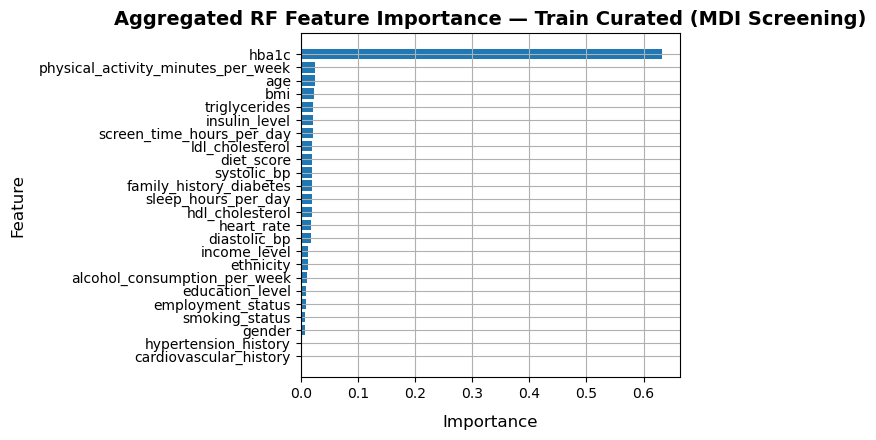

In [21]:
# Plot Aggregated Importance (all Predictors)
top_n_all = len(rf_importance_agg)

fig, ax = viz.plot_feature_importance_bar(
    rf_importance_agg,
    top_n=top_n_all,
    title="Aggregated RF Feature Importance — Train Curated (MDI Screening)",
)

viz.finalize_fig(
    fig,
    save_path=(
        (FIG_DIR / "rf_train_curated_feature_importance_aggregated.png")
        if SAVE_FIGS
        else None
    ),
    show=VERBOSE,
)

**Finding (Including `HbA1c`):**  
`HbA1c` accounts for a majority of total Random Forest importance. This is consistent with its clinical role as a diagnostic biomarker for diabetes.

Because Mean Decrease in Impurity (MDI) importance is relative, the dominance of `HbA1c` compresses the importance of remaining predictors, making it difficult to distinguish structural differences among them.  To construct a reduced model that still includes `HbA1c`, the remaining predictors are analyzed separately by renormalizing their importances.

### **5.2** Reduced Model Construction via Renormalized Importance

To determine a reduced predictor set while retaining `HbA1c`, the importance values of all non-`HbA1c` predictors are renormalized to sum to one. This isolates the relative contribution of the remaining predictors and allows cumulative importance thresholds to be evaluated without distortion from the dominant biomarker.

In [22]:
# RENORMALIZE NON-HbA1c IMPORTANCES

# Remove HbA1c Row - Treat HbA1c as Always-Included to Analyze the Rest
rf_non = rf_importance_agg.loc[rf_importance_agg["feature"] != "hba1c"].copy()
rf_non = rf_non.sort_values("importance", ascending=False).reset_index(drop=True)

# Renormalize Remaining Importances to Sum to 1
total_non = rf_non["importance"].sum()
rf_non["importance_renorm"] = rf_non["importance"] / total_non

# Cumulative Importance on the Renormalized Values
rf_non["cumulative_renorm"] = rf_non["importance_renorm"].cumsum()

In [23]:
# Display table
if VERBOSE:
    display(rf_non[["feature", "importance", "importance_renorm", "cumulative_renorm"]])

# Save table
io.save_table_csv(
    rf_non[["feature", "importance", "importance_renorm", "cumulative_renorm"]],
    TAB_DIR / "rf_train_curated_importance_non_hba1c_renormalized.csv",
    save=SAVE_TABLES,
)

io.save_table_tex(
    rf_non[["feature", "importance", "importance_renorm", "cumulative_renorm"]],
    TAB_DIR / "rf_train_curated_importance_non_hba1c_renormalized.tex",
    caption="Renormalized Random Forest Feature Importances (Non-HbA1c Predictors Only). Cumulative importance is computed after renormalizing to sum to one.",
    label="tab:rf_importance_renorm_non_hba1c",
    escape_underscore_cols=("feature",),
    save=SAVE_TABLES,
);

,feature,importance,importance_renorm,cumulative_renorm
0,physical_activity_minutes_per_week,0.025835,0.070231,0.070231
1,age,0.024671,0.067067,0.137298
2,bmi,0.023008,0.062547,0.199845
3,triglycerides,0.021647,0.058848,0.258693
4,insulin_level,0.021496,0.058436,0.317129
5,screen_time_hours_per_day,0.020732,0.056359,0.373488
6,ldl_cholesterol,0.020543,0.055846,0.429334
7,diet_score,0.020395,0.055443,0.484777
8,systolic_bp,0.020072,0.054565,0.539342
9,family_history_diabetes,0.019602,0.053289,0.592631


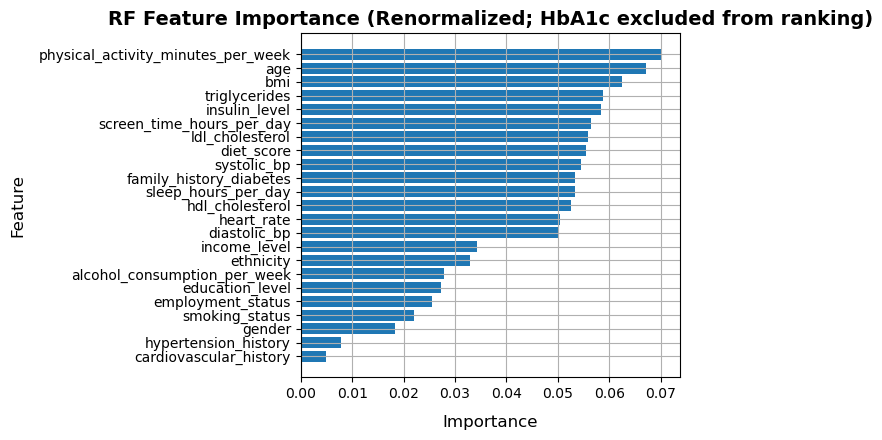

In [24]:
# Plot Renormalized Importance Barplot (all non-HbA1c Predictors)
rf_non_plot = rf_non[["feature", "importance_renorm"]].rename(
    columns={"importance_renorm": "importance"}
)

fig, ax = viz.plot_feature_importance_bar(
    rf_non_plot,
    top_n=len(rf_non_plot),
    title="RF Feature Importance (Renormalized; HbA1c excluded from ranking)",
)

viz.finalize_fig(
    fig,
    save_path=(FIG_DIR / "rf_importance_renorm_non_hba1c.png") if SAVE_FIGS else None,
    show=VERBOSE,
)

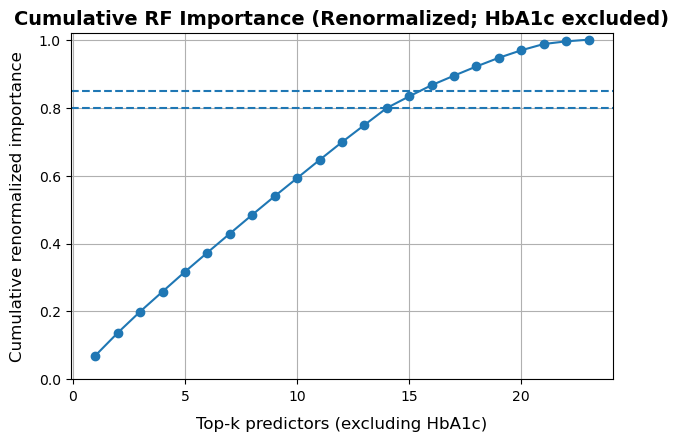

In [25]:
# Plot Cumulative Curve (Renormalized)
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(range(1, len(rf_non) + 1), rf_non["cumulative_renorm"].values, marker="o")
ax.axhline(0.80, linestyle="--")
ax.axhline(0.85, linestyle="--")
ax.set_xlabel("Top-k predictors (excluding HbA1c)")
ax.set_ylabel("Cumulative renormalized importance")
ax.set_title("Cumulative RF Importance (Renormalized; HbA1c excluded)")
ax.set_ylim(0, 1.02)
ax.grid(True)

viz.finalize_fig(
    fig,
    save_path=(FIG_DIR / "rf_cumulative_renorm_non_hba1c.png") if SAVE_FIGS else None,
    show=VERBOSE,
)

**Reduced Model Selection:**  

The cumulative renormalized importance reaches approximately 80\% at the inclusion of `diastolic_bp` (14 non-`HbA1c` predictors). This threshold captures a substantial majority of the relative importance among non-diagnostic predictors while reducing dimensionality.

In addition to the 80\% cumulative threshold, the importance profile exhibits a noticeable drop in magnitude immediately after `diastolic_bp`. Predictors ranked below this point contribute substantially smaller incremental importance values, indicating diminishing marginal contribution beyond this cutoff.

The reduced model is therefore defined as:

- `HbA1c`, plus  
- The top 14 non-`HbA1c` predictors ranked by renormalized importance.

This results in a 15-predictor structural model (1 diagnostic biomarker + 14 physiologic/lifestyle predictors) for nested comparison against the full curated model.

### **5.3** Save the Reduced Datasets

Using the selected predictor set defined above, reduced training and test datasets are constructed. The same predictors are retained in both datasets to ensure consistency in downstream modeling comparisons.

In [26]:
# Construct Reduced Predictor List
top_k_non_hba1c = 14
selected_non_hba1c = rf_non["feature"].iloc[:top_k_non_hba1c].tolist()

reduced_features = ["hba1c"] + selected_non_hba1c

# Ensure target included
reduced_cols = reduced_features + [sch.TARGET_COL]

train_reduced = train_curated_full[reduced_cols].copy()
test_reduced = test_curated_full[reduced_cols].copy()

# Save reduced datasets
io.save_processed_data(
    train_reduced,
    PROC_REDUCED_DIR / "train_reduced_structural.csv",
)

io.save_processed_data(
    test_reduced,
    PROC_REDUCED_DIR / "test_reduced_structural.csv",
)

# Save metadata
io.save_metadata_json(
    {
        "parent_dataset": "train_curated_full / test_curated_full",
        "construction_method": "Random Forest feature screening (MDI importance)",
        "hba1c_handling": "Always included; non-HbA1c features ranked by renormalized importance",
        "selection_rule": {
            "top_k_non_hba1c": top_k_non_hba1c,
            "approx_cumulative_importance_target": 0.80,
            "cutoff_feature": selected_non_hba1c[-1],
        },
        "selected_features_non_hba1c": selected_non_hba1c,
        "selected_features_full_model": reduced_features,
        "target_column": sch.TARGET_COL,
        "random_seed": SEED,
        "notes": (
            "Reduced dataset constructed for nested logistic regression comparison "
            "and downstream structural model comparison. "
            "Feature screening performed on training data only."
        ),
    },
    PROC_REDUCED_DIR / "reduced_structural.json",
)


if VERBOSE:
    print("Reduced model predictors:")
    print(reduced_features)
    print("Train reduced shape:", train_reduced.shape)

Reduced model predictors:
['hba1c', 'physical_activity_minutes_per_week', 'age', 'bmi', 'triglycerides', 'insulin_level', 'screen_time_hours_per_day', 'ldl_cholesterol', 'diet_score', 'systolic_bp', 'family_history_diabetes', 'sleep_hours_per_day', 'hdl_cholesterol', 'heart_rate', 'diastolic_bp']
Train reduced shape: (80000, 16)


### Section Summary

- Random Forest screening confirms `HbA1c` as the dominant predictor.
- To construct a reduced model without distorting importance rankings, non-`HbA1c` predictors were renormalized.
- The reduced model retains `HbA1c` and the top 14 non-`HbA1c` predictors, capturing approximately 80\% of renormalized cumulative importance.
- Both full and reduced datasets have been saved for subsequent logistic regression comparison.

---
## **6.** Logistic Regression - Full vs Reduced (ANOVA-style Nested Comparison via LRT)

This section compares a **full** vs **reduced** logistic regression using likelihood-based inference.

- Models are fit on **training data only**.
- Categorical variables are one-hot encoded.
- The reduced model is constructed to be **strictly nested** within the full model
  by reusing the same fitted encoder and masking encoded columns.

The "ANOVA" comparison is implemented as a **Likelihood Ratio Test (LRT)**:

$$\mathrm{LR} = 2(\ell_{\text{full}} - \ell_{\text{reduced}}),\quad \mathrm{LR} \sim \chi^2_{\Delta df}.$$

Outputs are saved to `results/tables/`.

### **6.1** Fit Logistic Regression Models - Full \& Reduced

In [27]:
# Load curated datasets (Full + Reduced)
train_full = io.load_processed_data(PROC_CURATED_DIR / "train_curated_full.csv")
test_full  = io.load_processed_data(PROC_CURATED_DIR / "test_curated_full.csv")

train_reduced = io.load_processed_data(PROC_REDUCED_DIR / "train_reduced_structural.csv")
test_reduced  = io.load_processed_data(PROC_REDUCED_DIR / "test_reduced_structural.csv")

if VERBOSE:
    print("train_full:   ", train_full.shape)
    print("test_full:    ", test_full.shape)
    print("train_reduced:", train_reduced.shape)
    print("test_reduced: ", test_reduced.shape)
    assert sch.TARGET_COL in train_full.columns
    assert sch.TARGET_COL in train_reduced.columns

train_full:    (80000, 25)
test_full:     (20000, 25)
train_reduced: (80000, 16)
test_reduced:  (20000, 16)


In [28]:
# Columns Present
cat_cols = [c for c in sch.CATEGORICAL_COLS if c in train_full.columns]
num_cols = [
    c for c in (sch.NUMERIC_COLS + [c for c in sch.BINARY_COLS if c != sch.TARGET_COL])
    if c in train_full.columns
]

if VERBOSE:
    print("Categorical:", cat_cols)
    print("Numeric/bin:", num_cols)

Categorical: ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']
Numeric/bin: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'insulin_level', 'hba1c', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']


In [29]:
# Fit FULL MLE logit on training data
full_fit = mdl.fit_logit_mle(
    train_full,
    target_col=sch.TARGET_COL,
    categorical_cols=cat_cols,
    numeric_cols=num_cols,
    add_intercept=True,
    maxiter=200,
    disp=False,
)

if VERBOSE:
    print(full_fit.result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                80000
Model:                          Logit   Df Residuals:                    79963
Method:                           MLE   Df Model:                           36
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                  0.4806
Time:                        18:39:17   Log-Likelihood:                -27964.
converged:                       True   LL-Null:                       -53842.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.7834      0.270    -84.348      0.000     -23.313     -22.254
x1            -0.0049      0.021     -0.230      0.818      -0.047       0.037
x2             0.1232      0.078      1.585      0.1

In [30]:
# Fit NESTED reduced model from the full design
# Keep predictors = all non-target columns in the reduced dataset
keep_predictors = [c for c in train_reduced.columns if c != sch.TARGET_COL]

assert set(keep_predictors).issubset(
    set(train_full.columns)
), "Reduced predictors must be subset of full."

reduced_fit = mdl.fit_logit_mle_reduced_from_full(
    full_fit,
    train_full,  # IMPORTANT: same rows, same y
    target_col=sch.TARGET_COL,
    keep_predictors=keep_predictors,
    maxiter=200,
    disp=False,
)

if VERBOSE:
    print(reduced_fit.result.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                80000
Model:                          Logit   Df Residuals:                    79984
Method:                           MLE   Df Model:                           15
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                  0.4804
Time:                        18:39:17   Log-Likelihood:                -27976.
converged:                       True   LL-Null:                       -53842.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -22.8357      0.262    -87.150      0.000     -23.349     -22.322
x1             0.0079      0.001      9.221      0.000       0.006       0.010
x2            -0.0013      0.000     -9.672      0.0

### **6.2** - Model Comparison via Likelihood Ratio Test

In [31]:
# Likelihood Ratio Test (ANOVA-style) on TRAIN
lrt = mdl.lrt_compare_nested(full_fit, reduced_fit)

lrt_df = pd.DataFrame([lrt])
if VERBOSE:
    display(lrt_df)

io.save_table_csv(lrt_df, TAB_DIR / "logit_lrt_full_vs_reduced.csv", save=SAVE_TABLES)
io.save_table_tex(
    lrt_df,
    TAB_DIR / "logit_lrt_full_vs_reduced.tex",
    caption="Likelihood Ratio Test (train-only) comparing nested logistic regression models: full vs reduced.",
    label="tab:lrt_full_vs_reduced",
    save=SAVE_TABLES,
);

,lr_stat,df_diff,p_value,llf_full,llf_reduced,aic_full,aic_reduced,bic_full,bic_reduced
0,22.894515,21.0,0.349628,-27964.297076,-27975.744334,56002.594152,55983.488668,56346.316083,56132.125178


The full and reduced logistic regression models were compared using a Likelihood Ratio Test (LRT). The LRT evaluates whether the additional parameters in the full model significantly improve model fit relative to the reduced specification.

The test statistic is defined as:

$$\mathrm{LR} = 2\left( \ell_{\text{full}} - \ell_{\text{reduced}} \right),$$

where $\ell_{\text{full}}$ and $\ell_{\text{reduced}}$ denote the maximized log-likelihoods of the full and reduced models, respectively.

Under standard regularity conditions, the LRT statistic follows a chi-squared distribution:

$$\mathrm{LR} \sim \chi^2_{\Delta df},$$

where $\Delta df$ is the difference in the number of estimated parameters between the two models.

**Note on Interpretation:**  
In logistic regression, the ANOVA-style comparison is implemented using a likelihood ratio (deviance) test for nested models.  
However, our reduced model was constructed using training-set supervised screening (Random Forest importance). Because the model specification was selected using the same outcome data used to fit the models, the usual chi-squared reference for the LRT p-value is best viewed as **descriptive rather than confirmatory**. 

Therefore, the LRT statistic together with information criteria (AIC/BIC) is used.

#### **Results**

- LR statistic = 22.89  
- Degrees of freedom = 21  
- p-value = 0.35  

The LRT statistic indicates only a small improvement in log-likelihood for the full model despite 21 additional parameters. Consistent with this, AIC and BIC favor the reduced model.

Information criteria further support this conclusion:

- AIC (reduced) < AIC (full)  
- BIC (reduced) < BIC (full)  

Although the full model contains 21 additional parameters, it yields only a negligible improvement in log-likelihood. The reduced model achieves comparable explanatory power with substantially fewer predictors.

### **Conclusion**

The reduced logistic regression model is selected for downstream predictive comparison due to its parsimony and statistically equivalent fit relative to the full model.

---

## **7.** Logistic Regression — Predictive Evaluation

In Section 6, MLE logistic regression was used for an ANOVA-style nested comparison (LRT) between structural model specifications.

This section shifts from inference to **predictive evaluation**.

Three model variants are evaluated:

1. **All predictors** 
   - The reduced specification chosen in Section 6 (includes `hba1c` plus the selected non-`hba1c` predictors).
2. **HbA1c-only**  
   - A single-predictor baseline using `hba1c` alone.
3. **Non-HbA1c ("everything else")**  
   - The selected reduced model with `hba1c` removed.

For each model:
- Fit on training data
- Choose classification threshold using **Youden's J (ROC-based)** on TRAIN only
- Evaluate on TEST using:
  - ROC AUC
  - PR AUC
  - Log Loss
  - Brier Score
  - Accuracy
  - Precision
  - Recall
  - F1
  - Specificity
  - Confusion Matrix

Threshold-free metrics (AUC, Brier, LogLoss) assess probability quality.
Threshold-based metrics evaluate operational performance.

All modeling decisions use training data only. Test data is used strictly for evaluation.

### **7.1** Load Dataset Variants

In [32]:
splits = io.load_and_build_three_variant_splits(
    proc_dir=PROC_REDUCED_DIR,
    train_filename="train_reduced_structural.csv",
    test_filename="test_reduced_structural.csv",
    target_col=sch.TARGET_COL,
    hba1c_col="hba1c",
)

train = splits.train_all
test = splits.test_all

train_hba1c = splits.train_hba1c
test_hba1c = splits.test_hba1c

train_nonhba1c = splits.train_non_hba1c
test_nonhba1c = splits.test_non_hba1c

In [33]:
# SANITY CHECKS: 3-variant splits (1st Usage)

# Basic shapes
assert (
    len(train) == len(train_hba1c) == len(train_nonhba1c)
), "Train row counts differ across variants."
assert (
    len(test) == len(test_hba1c) == len(test_nonhba1c)
), "Test row counts differ across variants."

# Target Present Everywhere
for name, df_ in [
    ("train", train),
    ("test", test),
    ("train_hba1c", train_hba1c),
    ("test_hba1c", test_hba1c),
    ("train_nonhba1c", train_nonhba1c),
    ("test_nonhba1c", test_nonhba1c),
]:
    assert sch.TARGET_COL in df_.columns, f"Missing target in {name}"

# HbA1c Membership Rules
assert "hba1c" in train.columns, "Expected hba1c in full/all train dataset."
assert list(train_hba1c.columns) == [
    "hba1c",
    sch.TARGET_COL,
], "HbA1c-only variant has unexpected columns."
assert (
    "hba1c" not in train_nonhba1c.columns
), "HbA1c unexpectedly present in non-hba1c variant."

# Column Consistency between train / test for each Variant
assert list(train.columns) == list(
    test.columns
), "Train/test column order differs for ALL variant."
assert list(train_hba1c.columns) == list(
    test_hba1c.columns
), "Train/test column order differs for HbA1c-only variant."
assert list(train_nonhba1c.columns) == list(
    test_nonhba1c.columns
), "Train/test column order differs for non-HbA1c variant."

# Ensure noo Shuffling of Rows
assert (
    train[sch.TARGET_COL].to_numpy().shape[0]
    == train_hba1c[sch.TARGET_COL].to_numpy().shape[0]
)
assert (
    train[sch.TARGET_COL].to_numpy() == train_hba1c[sch.TARGET_COL].to_numpy()
).all(), "Targets differ between ALL and HbA1c variants (train)."
assert (
    train[sch.TARGET_COL].to_numpy() == train_nonhba1c[sch.TARGET_COL].to_numpy()
).all(), "Targets differ between ALL and non-HbA1c variants (train)."

# Ensure no Missing Values Introduced in Slicing
assert (
    train.isna().sum().sum() == 0
), "Missing values found in train (ALL) after slicing."
assert test.isna().sum().sum() == 0, "Missing values found in test (ALL) after slicing."

if VERBOSE:
    print("Three-variant split checks passed.")
    print("ALL:", train.shape, test.shape)
    print("HbA1c-only:", train_hba1c.shape, test_hba1c.shape)
    print("Non-HbA1c:", train_nonhba1c.shape, test_nonhba1c.shape)

Three-variant split checks passed.
ALL: (80000, 16) (20000, 16)
HbA1c-only: (80000, 2) (20000, 2)
Non-HbA1c: (80000, 15) (20000, 15)


### **7.2** Fit Logistic Regression Models (MLE)

#### **7.2a** Fit Models

In [34]:
# Define per-Variant Column Types
cat_all, num_all = sch.cols_present(train)
cat_h, num_h = sch.cols_present(train_hba1c)
cat_nh, num_nh = sch.cols_present(train_nonhba1c)

assert (
    sch.TARGET_COL not in num_all
    and sch.TARGET_COL not in num_h
    and sch.TARGET_COL not in num_nh
)

# Fit ALL
fit_all = mdl.fit_logit_mle(
    train,
    target_col=sch.TARGET_COL,
    categorical_cols=cat_all,
    numeric_cols=num_all,
    add_intercept=True,
    maxiter=200,
    disp=False,
)

# Fit HbA1c-only
fit_hba1c = mdl.fit_logit_mle(
    train_hba1c,
    target_col=sch.TARGET_COL,
    categorical_cols=cat_h,
    numeric_cols=num_h,
    add_intercept=True,
    maxiter=200,
    disp=False,
)

# Fit non-HbA1c
fit_nonhba1c = mdl.fit_logit_mle(
    train_nonhba1c,
    target_col=sch.TARGET_COL,
    categorical_cols=cat_nh,
    numeric_cols=num_nh,
    add_intercept=True,
    maxiter=200,
    disp=False,
)

if VERBOSE:
    print("Converged flags:")
    print("  ALL:", fit_all.result.mle_retvals["converged"])
    print("  HbA1c:", fit_hba1c.result.mle_retvals["converged"])
    print("  non-HbA1c:", fit_nonhba1c.result.mle_retvals["converged"])

Converged flags:
  ALL: True
  HbA1c: True
  non-HbA1c: True


#### **7.2b** Predicted Probabilities

In [35]:
# ALL predictors
p_train_all = mdl.predict_proba_logit_mle(fit_all, train)
p_test_all = mdl.predict_proba_logit_mle(fit_all, test)

# HbA1c-only
p_train_hba1c = mdl.predict_proba_logit_mle(fit_hba1c, train_hba1c)
p_test_hba1c = mdl.predict_proba_logit_mle(fit_hba1c, test_hba1c)

# Non-HbA1c
p_train_nonhba1c = mdl.predict_proba_logit_mle(fit_nonhba1c, train_nonhba1c)
p_test_nonhba1c = mdl.predict_proba_logit_mle(fit_nonhba1c, test_nonhba1c)

if VERBOSE:
    print("Proba shapes:")
    print("  ALL        ", p_train_all.shape, p_test_all.shape)
    print("  HbA1c      ", p_train_hba1c.shape, p_test_hba1c.shape)
    print("  non-HbA1c  ", p_train_nonhba1c.shape, p_test_nonhba1c.shape)

    # Sanity Check: probabilities in [0,1]
    for name, p in [
        ("p_train_all", p_train_all),
        ("p_test_all", p_test_all),
        ("p_train_hba1c", p_train_hba1c),
        ("p_test_hba1c", p_test_hba1c),
        ("p_train_nonhba1c", p_train_nonhba1c),
        ("p_test_nonhba1c", p_test_nonhba1c),
    ]:
        assert np.all((p >= 0) & (p <= 1)), f"{name} has values outside [0,1]"

Proba shapes:
  ALL         (80000,) (20000,)
  HbA1c       (80000,) (20000,)
  non-HbA1c   (80000,) (20000,)


In [36]:
# Train-only Diagnostic : Convergence + Probability Spread to Flag Obvious Instability.
diag = mtx.logit_diagnostics_table(
    fits={"ALL": fit_all, "HbA1c": fit_hba1c, "non-HbA1c": fit_nonhba1c},
    p_train={"ALL": p_train_all, "HbA1c": p_train_hba1c, "non-HbA1c": p_train_nonhba1c},
)

display(diag)

io.save_table_csv(diag, TAB_DIR / "logit_train_diagnostics.csv", save=SAVE_TABLES)
io.save_table_tex(
    diag,
    TAB_DIR / "logit_train_diagnostics.tex",
    caption="Logistic regression training diagnostics: convergence and predicted-probability spread (train only).",
    label="tab:logit_train_diagnostics",
    save=SAVE_TABLES,
);

,model,converged,min,p01,median,p99,max,pct_lt_0.01,pct_gt_0.99
0,ALL,True,0.000129,0.002448,0.704898,0.999664,0.999998,0.032787,0.110225
1,HbA1c,True,0.000260,0.002642,0.706701,0.999576,0.999997,0.031075,0.104413
2,non-HbA1c,True,0.130154,0.314562,0.588491,0.884933,0.951935,0.000000,0.000000


#### **7.2c** Coefficients and Odds Ratios

In [37]:
tbl_all = mdl.logit_coef_table(
    fit_all, conf_level=0.95, exponentiate=True, include_intercept=False
)
tbl_h = mdl.logit_coef_table(
    fit_hba1c, conf_level=0.95, exponentiate=True, include_intercept=False
)
tbl_nh = mdl.logit_coef_table(
    fit_nonhba1c, conf_level=0.95, exponentiate=True, include_intercept=False
)

# Sort by p-value
tbl_all = tbl_all.sort_values("p_value").reset_index(drop=True).round(4)
tbl_h = tbl_h.sort_values("p_value").reset_index(drop=True).round(4)
tbl_nh = tbl_nh.sort_values("p_value").reset_index(drop=True).round(4)

# Save (CSV + LaTeX)
io.save_table_csv(tbl_all, TAB_DIR / "logit_coef_all.csv", save=SAVE_TABLES)
io.save_table_tex(
    tbl_all,
    TAB_DIR / "logit_coef_all.tex",
    caption="Logistic regression coefficients and odds ratios (ALL predictors; train fit).",
    label="tab:logit_coef_all",
    escape_underscore_cols=("term",),
    save=SAVE_TABLES,
)

io.save_table_csv(tbl_h, TAB_DIR / "logit_coef_hba1c_only.csv", save=SAVE_TABLES)
io.save_table_tex(
    tbl_h,
    TAB_DIR / "logit_coef_hba1c_only.tex",
    caption="Logistic regression coefficients and odds ratios (HbA1c-only; train fit).",
    label="tab:logit_coef_hba1c_only",
    escape_underscore_cols=("term",),
    save=SAVE_TABLES,
)

io.save_table_csv(tbl_nh, TAB_DIR / "logit_coef_non_hba1c.csv", save=SAVE_TABLES)
io.save_table_tex(
    tbl_nh,
    TAB_DIR / "logit_coef_non_hba1c.tex",
    caption="Logistic regression coefficients and odds ratios (non-HbA1c predictors; train fit).",
    label="tab:logit_coef_non_hba1c",
    escape_underscore_cols=("term",),
    save=SAVE_TABLES,
)

if VERBOSE:
    print("ALL VARIBLES Model")
    display(tbl_all)
    print("HbA1c Model")
    display(tbl_h)
    print("NO HbA1c Model")
    display(tbl_nh)

ALL VARIBLES Model


,term,coef,std_err,z,p_value,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
0,hba1c,3.5558,0.0261,136.3492,0.0000,3.5047,3.6069,35.0157,33.2709,36.8520
1,family_history_diabetes,0.4986,0.0282,17.6988,0.0000,0.4434,0.5538,1.6464,1.5579,1.7398
2,physical_activity_minutes_per_week,-0.0013,0.0001,-9.6720,0.0000,-0.0015,-0.0010,0.9987,0.9985,0.9990
3,age,0.0079,0.0009,9.2215,0.0000,0.0062,0.0096,1.0079,1.0062,1.0096
4,bmi,0.0138,0.0037,3.7155,0.0002,0.0065,0.0211,1.0139,1.0066,1.0214
5,hdl_cholesterol,-0.0038,0.0011,-3.4224,0.0006,-0.0060,-0.0016,0.9962,0.9940,0.9984
6,diet_score,-0.0154,0.0061,-2.5231,0.0116,-0.0273,-0.0034,0.9847,0.9731,0.9966
7,triglycerides,0.0007,0.0003,2.4913,0.0127,0.0001,0.0012,1.0007,1.0001,1.0012
8,ldl_cholesterol,0.0005,0.0004,1.3900,0.1645,-0.0002,0.0012,1.0005,0.9998,1.0012
9,systolic_bp,0.0010,0.0009,1.1104,0.2668,-0.0008,0.0028,1.0010,0.9992,1.0028


HbA1c Model


,term,coef,std_err,z,p_value,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
0,hba1c,3.624,0.0259,139.8287,0.0,3.5732,3.6748,37.4869,35.6303,39.4404


NO HbA1c Model


,term,coef,std_err,z,p_value,ci_low,ci_high,odds_ratio,or_ci_low,or_ci_high
0,family_history_diabetes,1.1240,0.0204,55.1450,0.0000,1.0841,1.1640,3.0772,2.9567,3.2026
1,age,0.0176,0.0006,29.0252,0.0000,0.0164,0.0188,1.0177,1.0165,1.0190
2,physical_activity_minutes_per_week,-0.0025,0.0001,-26.7983,0.0000,-0.0027,-0.0023,0.9975,0.9974,0.9977
3,bmi,0.0290,0.0026,10.9686,0.0000,0.0238,0.0342,1.0294,1.0241,1.0348
4,diet_score,-0.0380,0.0043,-8.8232,0.0000,-0.0465,-0.0296,0.9627,0.9546,0.9708
5,hdl_cholesterol,-0.0065,0.0008,-8.2537,0.0000,-0.0080,-0.0050,0.9935,0.9920,0.9951
6,insulin_level,0.0093,0.0017,5.6378,0.0000,0.0061,0.0126,1.0094,1.0061,1.0127
7,triglycerides,0.0011,0.0002,5.6137,0.0000,0.0007,0.0014,1.0011,1.0007,1.0014
8,screen_time_hours_per_day,0.0148,0.0030,4.8575,0.0000,0.0088,0.0208,1.0149,1.0089,1.0210
9,systolic_bp,0.0016,0.0006,2.4759,0.0133,0.0003,0.0029,1.0016,1.0003,1.0029


#### **Summary** (Fit + Coefficients)

- **All three logistic regression variants converged** (ALL, `HbA1c`-only, non-HbA1c), indicating stable MLE estimation under this specification.
- **HbA1c is the dominant signal**:
  - In both the ALL and HbA1c-only models, HbA1c has a very large positive effect with a tight confidence interval, consistent with its diagnostic role.
  - The HbA1c coefficient is **very similar** in the ALL vs HbA1c-only fits, suggesting the additional predictors do not materially change its estimated contribution.
- **When HbA1c is removed, remaining predictors expand in magnitude**:
  - Risk-factor variables (e.g., family history, age, BMI, select lab/lifestyle measures) become larger and more significant, reflecting reallocation of predictive signal once the dominant biomarker is excluded.
- **No immediate numerical red flags suggesting the need for penalization**:
  - All models converged; predicted probabilities are valid; coefficients/SEs are finite.

**Decision:** Proceed with standard MLE (no RIDGE/penalized logistic regression) for the predictive evaluation steps that follow. We will revisit penalization only if later steps show signs of separation/instability.

### **7.3** Choose Classification Threshold

In [38]:
y_train = train[sch.TARGET_COL].to_numpy()

threshold_rows_youden = []
for name, p in [
    ("ALL", p_train_all),
    ("HbA1c", p_train_hba1c),
    ("non-HbA1c", p_train_nonhba1c),
]:
    d = mtx.pick_threshold(y_train, p, method="youden")
    threshold_rows_youden.append({"model": name, **d})

thresh_tbl_youden = pd.DataFrame(threshold_rows_youden)

if VERBOSE:
    display(thresh_tbl_youden)

io.save_table_csv(
    thresh_tbl_youden, TAB_DIR / "logit_thresholds_youden_train.csv", save=SAVE_TABLES
)
io.save_table_tex(
    thresh_tbl_youden,
    TAB_DIR / "logit_thresholds_youden_train.tex",
    caption="Train-only classification thresholds for logistic regression variants using Youden's J on the ROC curve.",
    label="tab:logit_thresholds_youden_train",
    save=SAVE_TABLES,
)

,model,best_threshold,best_j,best_tpr,best_fpr,best_specificity
0,ALL,0.677347,0.814526,0.842493,0.027967,0.972033
1,HbA1c,0.691456,0.851119,0.851119,0.000000,1.000000
2,non-HbA1c,0.610276,0.230905,0.529980,0.299075,0.700925


WindowsPath('C:/Users/etoob/OneDrive/Documents/School/STATS/STAT587_DS1/Project/diabetes-prediction-ds1/results/tables/logit_thresholds_youden_train.tex')

In [39]:
# Sensitivity Check via F1-based threshold
threshold_rows_f1 = []
for name, p in [
    ("ALL", p_train_all),
    ("HbA1c", p_train_hba1c),
    ("non-HbA1c", p_train_nonhba1c),
]:
    d = mtx.pick_threshold_by_f1(y_train, p)
    threshold_rows_f1.append(
        {"model": name, "best_threshold": d["best_threshold"], "best_f1": d["best_f1"]}
    )

thresh_tbl_f1 = pd.DataFrame(threshold_rows_f1)

if VERBOSE:
    display(thresh_tbl_f1)

io.save_table_csv(
    thresh_tbl_f1, TAB_DIR / "logit_thresholds_f1_train.csv", save=SAVE_TABLES
)
io.save_table_tex(
    thresh_tbl_f1,
    TAB_DIR / "logit_thresholds_f1_train.tex",
    caption="Train-only thresholds for logistic regression variants chosen to maximize F1 (sensitivity check).",
    label="tab:logit_thresholds_f1_train",
    save=SAVE_TABLES,
);

,model,best_threshold,best_f1
0,ALL,0.6225,0.905463
1,HbA1c,0.6225,0.904021
2,non-HbA1c,0.3775,0.751561


#### **Summary** (Threshold Selection)

Thresholds were computed using both:

- **Youden’s J** (maximizing TPR − FPR on the ROC curve), and  
- **F1 score** (maximizing the harmonic mean of precision and recall).

These criteria optimize different objectives:

- Youden’s J balances sensitivity and specificity and is independent of class prevalence, making it standard in diagnostic evaluation.
- F1 focuses on the positive class and ignores true negatives, often shifting thresholds when class separation is weaker.

**Key findings:**

- **HbA1c-only achieves the strongest discrimination**, with the highest Youden’s J ($\approx 0.85$).  
  - At its selected threshold (~0.69), the model attains **perfect specificity (FPR = 0)** while maintaining high sensitivity (~85%), indicating near-separation of classes based on HbA1c alone.

- The **ALL model performs similarly but not better** (J $\approx 0.81$), suggesting that adding additional predictors does not materially improve discrimination beyond HbA1c.

- The **non-HbA1c model performs substantially worse** (J $\approx0.23$), with markedly weaker sensitivity–specificity tradeoff, confirming that most predictive signal resides in HbA1c.

- For the stronger models (**ALL** and **HbA1c-only**), thresholds selected via Youden’s J and F1 were nearly identical, indicating a stable operating region and well-ranked predicted probabilities. In contrast, the **non-HbA1c model** exhibited greater divergence between criteria, reflecting weaker class separation.

**Decision:**  
**Youden’s J** is used as the operational threshold rule, as it aligns with ROC-based evaluation and balanced diagnostic interpretation. These thresholds are fixed and will be applied unchanged to the test set.

**Interpretation:**  
HbA1c overwhelmingly drives discriminative performance. Removing it results in a dramatic loss of classification quality, while adding additional predictors yields minimal incremental improvement.

### **7.4** Evaluate on Test Set (Fixed Train-Selected Thresholds)

This subsection reports **predictive performance on the held-out test set** using **fixed probability thresholds** selected on the training set.

**Policy (no leakage):**
- Thresholds are selected using training data only (Section 7.3).
- No refitting or threshold tuning is performed using test data.
- The test set is used strictly once for final evaluation.

Two threshold-selection rules were computed on training data:
- **Youden’s J** (ROC-based) — balances sensitivity and specificity.
- **F1-optimal** — prioritizes harmonic mean of precision and recall.

Both are reported for completeness; **Youden’s J** is used as the primary operating point unless otherwise stated.

#### **7.4a** - Build Fixed Threshold Maps from Train-Only Selection Results

In [40]:
# Build Fixed Threshold Maps from 7.3 Results
youden_thresholds = {
    row["model"]: float(row["best_threshold"])
    for _, row in thresh_tbl_youden.iterrows()
}

f1_thresholds = {
    row["model"]: float(row["best_threshold"]) for _, row in thresh_tbl_f1.iterrows()
}

if VERBOSE:
    thr_display = (
        thresh_tbl_youden[["model", "best_threshold"]]
        .rename(columns={"best_threshold": "thr_youden"})
        .merge(
            thresh_tbl_f1[["model", "best_threshold"]].rename(
                columns={"best_threshold": "thr_f1"}
            ),
            on="model",
            how="left",
        )
    )

    thr_display["thr_youden"] = thr_display["thr_youden"].astype(float).round(4)
    thr_display["thr_f1"] = thr_display["thr_f1"].astype(float).round(4)

    display(thr_display)

# Sanity checks
for name in ["ALL", "HbA1c", "non-HbA1c"]:
    assert name in youden_thresholds, f"Missing Youden threshold for {name}"
    assert name in f1_thresholds, f"Missing F1 threshold for {name}"
    assert 0.0 < youden_thresholds[name] < 1.0
    assert 0.0 < f1_thresholds[name] < 1.0

,model,thr_youden,thr_f1
0,ALL,0.6773,0.6225
1,HbA1c,0.6915,0.6225
2,non-HbA1c,0.6103,0.3775


#### **7.4b** Test Metrics Using Youden’s J Thresholds (Primary)

The following table evaluates each logistic regression variant on the test set using the **Youden-selected** probability thresholds determined from training data.

- No refitting or retuning is performed on the test set.
- Thresholds are fixed from Section 7.3.
- Reported metrics include both ranking-based (ROC AUC, PR AUC) and threshold-dependent measures (accuracy, precision, recall, F1).

The compact table is shown below; the full metrics table (including confusion matrix entries) is saved as a CSV artifact.

In [41]:
# Evaluate on TEST using Youden Thresholds (Primary)

y_test = test[sch.TARGET_COL].to_numpy()

test_results_youden = {}
for model_name, p_test in [
    ("ALL", p_test_all),
    ("HbA1c", p_test_hba1c),
    ("non-HbA1c", p_test_nonhba1c),
]:
    thr = float(youden_thresholds[model_name])
    test_results_youden[model_name] = mtx.compute_classification_metrics(
        y_true=y_test,
        y_prob=p_test,
        threshold=thr,
    )

# Full table (includes tn/fp/fn/tp)
df_test_youden_full = mtx.metrics_to_frame(test_results_youden).reset_index()

# Compact for display + LaTeX
df_test_youden_compact = mtx.compact_metrics_frame(df_test_youden_full)

if VERBOSE:
    display(df_test_youden_compact)

# Save full CSV (artifact)
io.save_table_csv(
    df_test_youden_full,
    TAB_DIR / "logit_test_eval_youden_full.csv",
    save=SAVE_TABLES,
)

# Save compact LaTeX (paper body)
io.save_table_tex(
    df_test_youden_compact,
    TAB_DIR / "logit_test_eval_youden_compact.tex",
    caption="Test-set evaluation of logistic regression variants using Youden-selected thresholds (training-only selection).",
    label="tab:logit_test_eval_youden",
    save=SAVE_TABLES,
);

,model,threshold,roc_auc,pr_auc,log_loss,brier,accuracy,precision,recall,f1
0,ALL,0.677347,0.936145,0.967813,0.340865,0.100146,0.89455,0.975118,0.845833,0.905886
1,HbA1c,0.691456,0.935156,0.967568,0.344885,0.101271,0.91265,1.000000,0.854417,0.921494
2,non-HbA1c,0.610276,0.662618,0.743012,0.631521,0.221080,0.59855,0.723769,0.535167,0.615340


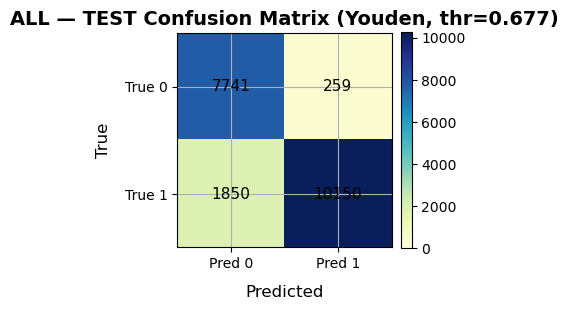

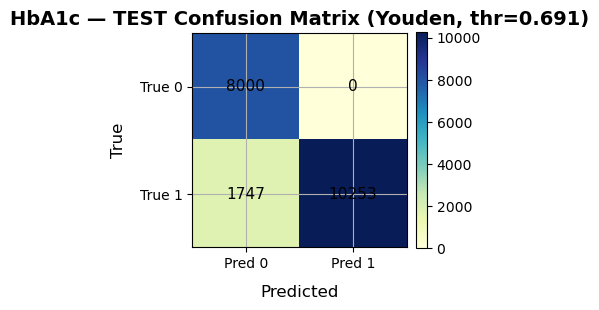

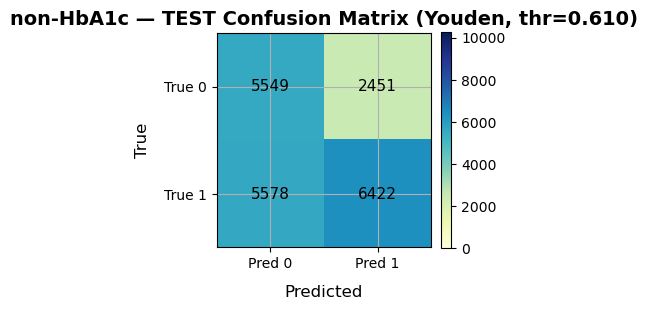

In [42]:
# Confusion Matrices (Youden, TEST)
global_vmax = df_test_youden_full[["tn", "fp", "fn", "tp"]].to_numpy().max()

for _, row in df_test_youden_full.iterrows():
    model = row["model"]
    thr = row["threshold"]

    fig, ax = viz.plot_confusion_matrix_binary(
        tn=int(row["tn"]),
        fp=int(row["fp"]),
        fn=int(row["fn"]),
        tp=int(row["tp"]),
        title=f"{model} — TEST Confusion Matrix (Youden, thr={thr:.3f})",
        normalize=False,
        cmap="YlGnBu",
        vmin=0.0,
        vmax=global_vmax,
    )

    viz.finalize_fig(
        fig,
        save_path=(
            (FIG_DIR / f"logit_test_cm_youden_{model}.png") if SAVE_FIGS else None
        ),
        show=VERBOSE,
    )

#### **7.4c** Threshold-Rule Sensitivity (Youden vs F1)

Threshold selection affects the operating point (precision/recall and error tradeoffs) even when
threshold-free ranking metrics (ROC AUC, PR AUC) remain unchanged.

This subsection reports a **side-by-side comparison** of test-set performance under:
- **Youden’s J thresholds** (primary)
- **F1-optimal thresholds** (secondary)

The comparison table is intended for the appendix; it uses **fixed train-selected thresholds**
and does not refit or tune on the test set.

In [43]:
# Evaluate on TEST using F1 Thresholds (Secondary)
y_test = test[sch.TARGET_COL].to_numpy()

test_results_f1 = {}
for model_name, p_test in [
    ("ALL", p_test_all),
    ("HbA1c", p_test_hba1c),
    ("non-HbA1c", p_test_nonhba1c),
]:
    thr = f1_thresholds[model_name]
    test_results_f1[model_name] = mtx.compute_classification_metrics(
        y_true=y_test,
        y_prob=p_test,
        threshold=thr,
    )

# Full frames (include tn/fp/fn/tp for reproducibility)
test_eval_f1_full = mtx.metrics_to_frame(test_results_f1).reset_index()
if VERBOSE:
    display(test_eval_f1_full)

,model,threshold,roc_auc,pr_auc,log_loss,brier,accuracy,precision,recall,f1,tn,fp,fn,tp
0,ALL,0.6225,0.936145,0.967813,0.340865,0.100146,0.89405,0.947793,0.871417,0.908002,7424.0,576.0,1543.0,10457.0
1,HbA1c,0.6225,0.935156,0.967568,0.344885,0.101271,0.89290,0.948254,0.868917,0.906853,7431.0,569.0,1573.0,10427.0
2,non-HbA1c,0.3775,0.662618,0.743012,0.631521,0.221080,0.61530,0.612229,0.978750,0.753271,561.0,7439.0,255.0,11745.0


In [44]:
#  Build the appendix comparison table (2 rows per model)
cmp_long_full = mtx.stack_threshold_method_results(
    df_youden_full=df_test_youden_full,
    df_f1_full=test_eval_f1_full,
    method_labels=("youden", "f1"),
)

# Sort for readability: model, then method
cmp_long_full = cmp_long_full.sort_values(["model", "method"]).reset_index(drop=True)

if VERBOSE:
    display(cmp_long_full)

# SAVE 
io.save_table_csv(
    cmp_long_full,
    TAB_DIR / "logit_test_threshold_rule_comparison_full.csv",
    save=SAVE_TABLES,
)

io.save_table_tex(
    cmp_long_full,
    TAB_DIR / "logit_test_threshold_rule_comparison_compact.tex",
    caption="Test-set performance under train-selected thresholds: Youden’s J vs F1-optimal (two rows per model).",
    label="tab:logit_test_threshold_rule_comparison",
    save=SAVE_TABLES,
);

,model,method,threshold,roc_auc,pr_auc,log_loss,brier,accuracy,precision,recall,f1,tn,fp,fn,tp
0,ALL,f1,0.622500,0.936145,0.967813,0.340865,0.100146,0.89405,0.947793,0.871417,0.908002,7424.0,576.0,1543.0,10457.0
1,ALL,youden,0.677347,0.936145,0.967813,0.340865,0.100146,0.89455,0.975118,0.845833,0.905886,7741.0,259.0,1850.0,10150.0
2,HbA1c,f1,0.622500,0.935156,0.967568,0.344885,0.101271,0.89290,0.948254,0.868917,0.906853,7431.0,569.0,1573.0,10427.0
3,HbA1c,youden,0.691456,0.935156,0.967568,0.344885,0.101271,0.91265,1.000000,0.854417,0.921494,8000.0,0.0,1747.0,10253.0
4,non-HbA1c,f1,0.377500,0.662618,0.743012,0.631521,0.221080,0.61530,0.612229,0.978750,0.753271,561.0,7439.0,255.0,11745.0
5,non-HbA1c,youden,0.610276,0.662618,0.743012,0.631521,0.221080,0.59855,0.723769,0.535167,0.615340,5549.0,2451.0,5578.0,6422.0


#### **Summary** (Test-Set Evaluation)

Test-set performance confirms the training-set findings.

- The **`HbA1c`-only model achieves nearly identical ROC AUC** to the ALL model ($\approx$ 0.935 vs 0.936), indicating that additional predictors provide minimal improvement in ranking performance.
- Under the Youden-selected operating point, the `HbA1c`-only model attains **perfect precision (no false positives)** while maintaining strong recall (~85%), yielding the highest overall F1 and accuracy among the three models.
- The ALL model performs similarly but does not materially outperform `HbA1c`-only, suggesting negligible incremental predictive value from the additional covariates.
- The non-`HbA1c` model exhibits substantially weaker discrimination (ROC AUC $\approx$ 0.66) and markedly inferior threshold-based performance, confirming that most predictive signal resides in `HbA1c`.

Comparing threshold-selection criteria:
- For the stronger models (ALL and `HbA1c`-only), Youden and F1 thresholds yield very similar test-set results, indicating a stable operating region.
- For the weaker non-`HbA1c` model, F1 thresholding substantially increases recall at the expense of specificity, illustrating how threshold criteria can dramatically alter operating characteristics when class separation is limited.

Overall, `HbA1c` dominates predictive performance, and additional risk-factor variables contribute minimal incremental discrimination beyond this biomarker.

### **7.5** Threshold-Free Discrimination and Calibration Diagnostics

This section evaluates model performance independent of any fixed classification threshold.

Section 7.4 examined performance at specific operating points. The diagnostics below assess:

- **Discrimination** — the ability to rank positives above negatives.
- **Calibration** — the agreement between predicted probabilities and observed outcome frequencies.

All evaluations are performed on the held-out test set.

#### **7.5a** ROC Curves (Discrimination)

Receiver Operating Characteristic (ROC) curves evaluate ranking performance
across all possible classification thresholds.

The Area Under the ROC Curve (AUC) represents the probability that a randomly selected positive instance receives a higher predicted probability than a randomly selected negative instance.

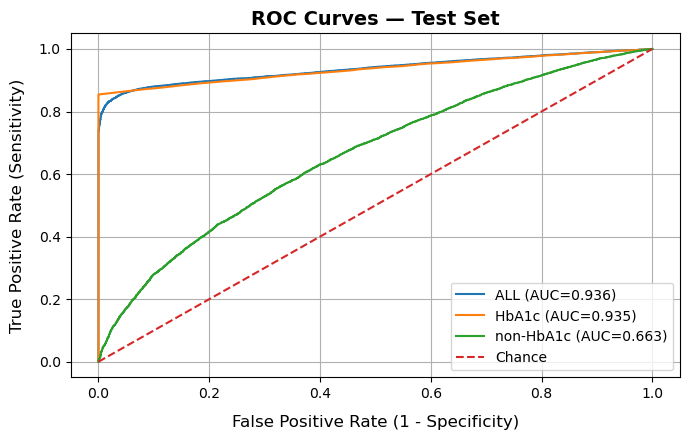

In [45]:
# ROC Curves (Test Set)

model_probs = {
    "ALL": p_test_all,
    "HbA1c": p_test_hba1c,
    "non-HbA1c": p_test_nonhba1c,
}

fig, ax = viz.plot_multiple_roc_curves(
    y_true=y_test,
    model_probas=model_probs,
    title="ROC Curves — Test Set",
)

viz.finalize_fig(
    fig,
    save_path=(FIG_DIR / "logit_test_roc_curves.png") if SAVE_FIGS else None,
    show=VERBOSE,
)

#### **7.5b** Precision–Recall Curves

Precision–Recall (PR) curves are particularly informative under class imbalance.

Average Precision (AP) summarizes performance by integrating precision over recall levels.

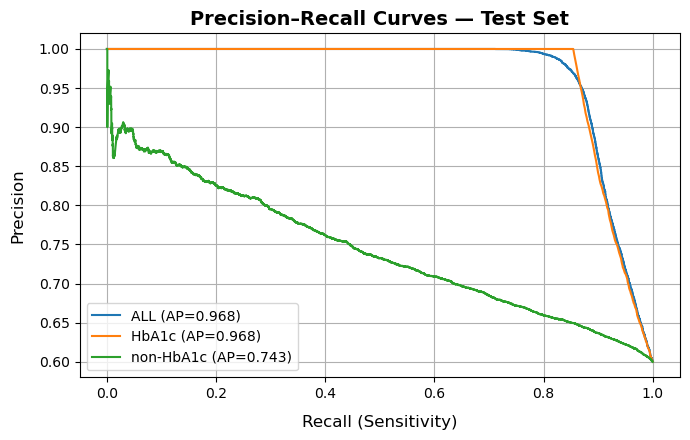

In [46]:
# Precision–Recall Curves (Test Set)

fig, ax = viz.plot_multiple_pr_curves(
    y_true=y_test,
    model_probas=model_probs,
    title="Precision–Recall Curves — Test Set",
)

viz.finalize_fig(
    fig,
    save_path=(FIG_DIR / "logit_test_pr_curves.png") if SAVE_FIGS else None,
    show=VERBOSE,
)

#### **7.5c** Calibration Curves

Calibration curves compare predicted probabilities to observed event frequencies.

A perfectly calibrated model lies on the 45° diagonal line. Deviations from this line indicate over- or under-confidence in predicted probabilities.

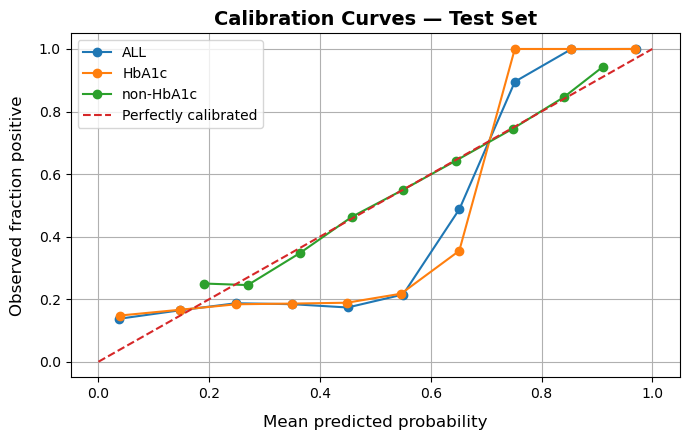

In [48]:
# Calibration Curves (Test Set)
fig, ax = viz.plot_multiple_calibration_curves(
    y_true=y_test,
    model_probas=model_probs,
    n_bins=10,
    strategy="uniform",
    title="Calibration Curves — Test Set",
)

viz.finalize_fig(
    fig,
    save_path=(FIG_DIR / "logit_test_calibration_curves.png") if SAVE_FIGS else None,
    show=VERBOSE,
)

#### **Summary** (Threshold-Free Discrimination and Calibration)

Threshold-free diagnostics reinforce the conclusions drawn from fixed-threshold evaluation.

**Discrimination.**  
ROC and Precision–Recall curves show that the **ALL** and **HbA1c-only** models are nearly indistinguishable in ranking performance. Their curves overlap across the full operating range, with nearly identical ROC AUC and Average Precision and **ALL** performing only slightly worse. In contrast, the **non-HbA1c** model exhibits substantially weaker discrimination, confirming that most predictive signal resides in HbA1c.

**Calibration.**  
The overlaid calibration curves reveal meaningful differences in probability reliability:

- The **ALL** and **HbA1c-only** models display similar calibration behavior. In the mid-probability range ($\approx$ 0.3–0.6), observed event frequencies remain relatively low, followed by a sharp increase in the highest predicted-probability bins. This pattern indicates that while these models rank well, predicted probabilities in intermediate ranges may be overconfident.
  
- The **non-HbA1c** model exhibits a more gradual and approximately linear relationship between predicted and observed probabilities, appearing closer to the diagonal across much of the range. However, this apparent calibration quality occurs alongside substantially weaker discrimination.

These findings illustrate an important distinction between discrimination and calibration. The strongest models (**ALL** and **HbA1c-only**) achieve excellent ranking performance but exhibit some probability miscalibration, whereas the weaker model demonstrates comparatively smoother calibration at the expense of predictive separation.

Overall, threshold-free diagnostics confirm that **HbA1c** accounts for nearly all discriminative capability in the data, with minimal incremental benefit from additional covariates.

### **Logistic Regression Summary**

Three model variants were fit on logistic regression and evaluated using both threshold-based and threshold-free diagnostics on a held-out test set:
- **ALL** predictors
- **HbA1c**-only
- **non-HbA1c** predictors

Across all evaluation criteria, results consistently indicate that **HbA1c dominates predictive performance**.

**Discrimination.**  
ROC and Precision–Recall analyses show that the **ALL** and **HbA1c**-only models achieve nearly identical ranking performance, with overlapping curves and indistinguishable AUC/AP values. In contrast, the **non-HbA1c** model demonstrates substantially weaker discrimination. This confirms that most class-separating information is captured by **HbA1c**.

**Threshold-Based Classification.**  
Using train-selected Youden thresholds, the **HbA1c-only** model achieves the highest accuracy and F1 score while maintaining perfect specificity. The ALL model performs similarly but does not materially improve upon **HbA1c** alone, indicating negligible incremental predictive value from additional covariates. The **non-HbA1c** model performs markedly worse across all threshold-based metrics.

**Threshold Sensitivity.**  
For the stronger models, Youden and F1 thresholding yield similar operating characteristics, indicating a stable decision region. For the weaker **non-HbA1c** model, threshold selection substantially alters the precision–recall tradeoff, reflecting limited class separation.

**Calibration.**  
Calibration curves reveal that the strongest models, while highly discriminative, exhibit some probability miscalibration in intermediate probability ranges. The **non-HbA1c** model displays smoother calibration but substantially weaker discrimination. This highlights the distinction between ranking ability and probability reliability.

**Overall Conclusion.**  
The findings provide consistent evidence that `HbA1c` alone accounts for nearly all predictive signal in the dataset. Additional patient-level health and risk-factor variables contribute minimal incremental discrimination beyond this biomarker. Removing `HbA1c` results in a pronounced decline in performance across both discrimination and classification metrics.

This supports the conclusion that, within this modeling framework, `HbA1c` is the primary driver of diabetes prediction performance.

---
---
---
---
---

---
---
---
---
---

---

## **8.** Method 2 &ndash; Random Forest

Random forests capture nonlinear relationships and interactions and provide feature importance measures for comparison with logistic regression.

In [ ]:
# Random Forest
# TODO: Implement in src.modeling

# Example intended flow:
# metrics_rf, model_rf = src.modeling.fit_random_forest(X_train, y_train, X_test, y_test, seed=SEED)
# add_result("Random Forest", metrics_rf)

pass

---

## **9.** Method 3 &ndash; Gradient Boosting (XGBoost)

Gradient boosting is evaluated as a high-capacity ensemble method. Compare its performance and trade-offs to random forests and logistic regression.

In [ ]:
# XGBoost
# TODO: Implement in src.modeling (requires xgboost package)

# Example intended flow:
# metrics_xgb, model_xgb = src.modeling.fit_xgboost(X_train, y_train, X_test, y_test, seed=SEED)
# add_result("XGBoost", metrics_xgb)

pass

---

## **10.** Method 4 (Optional) &ndash; Shallow Neural Network (MLP)

In [ ]:
# Optional MLP
# TODO: Implement if included

pass

---

## **11.** Model Comparison

Results compiled across all methods into:
- a final comparison table
- performance visualizations (e.g., ROC curves, metric bar charts)
- interpretability comparisons (coefficients vs feature importances)

Tables are saved to `results/tables/` and figures to `results/figures/`.

In [ ]:
# Model comparison
results_df = pd.DataFrame(results)
results_df

In [ ]:
# Save comparison table (CSV). 
# Add LaTeX export later - Utilize src files for functionality.
"""
OUT_CSV = TAB_DIR / "model_comparison.csv"
results_df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
"""

---

## **12.** Discussion and Conclusions

Summarize:
- which model performed best and why
- most influential predictors (and whether consistent across models)
- interpretability vs performance trade-offs
- limitations (synthetic data, documentation mismatch)
- next steps / improvements

---

## **13.** Minimal Reproducibility Notes

To reproduce:
1. Ensure raw data is present in `data/raw/`
2. Run this notebook top-to-bottom

Notes:
- Seed: `SEED = 587`
- Generated outputs: `data/processed/`, `results/figures/`, `results/tables/`
- Full environment/setup instructions will be documented in `README.md`